# YOUR NAME HERE: 

# A5 Convolutional Neural Network (Total 150pts)


## 1. Import libraries (Total 6pts)

### 1.1 Import torch, torchvision, torchvision.transforms, torch.utils.data and torch.nn (6pts)

In [2]:
# TODO
import torch, torchvision, torchvision.transforms as transforms, torch.utils.data, torch.nn as nn
import torch.functional as F

## 2. Data Preparation (Total 32pts)


### 2.1 Image Transformation (12pts)
Define a transformation pipeline using torchvision.transforms.Compose.

In the pipeline, use **ColorJitter, GaussianBlur, RandomHorizontalFlip, ToTensor and Normalize** from the transforms library.

For the first four transformations, use suitable parameters of your informed choice. At the end, normalize the images with mean 0.5 and variance 0.5.

Read about these transformations here: https://pytorch.org/vision/0.9/transforms.html

In [3]:
# TODO
pipeline = torchvision.transforms.Compose([
    transforms.ColorJitter(),
    transforms.GaussianBlur(1),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])

### 2.2 Prepare train and test set by loading CIFAR10 dataset from torchvision.datasets. (4pts)
Make sure you are using the **transform** pipeline (you just wrote in task #2.1) on both train and test set. 

**Hint:** Preparing train and test sets can be directly achieved by utilizing the class parameters.


Read about CIFAR10 dataset class in PyTorch: https://pytorch.org/vision/0.9/datasets.html#cifar

In [4]:
# TODO
import torchvision.datasets as datasets

cifar_trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=pipeline)

cifar_testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=pipeline)

100%|██████████| 170498071/170498071 [00:02<00:00, 67636093.11it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


### 2.3 Use torch.utils.data.random_split() to make a validation set from the training set with 80:20 split. (3pts)

Make sure the training set you'll use after this point excludes the validation set of images 


In [5]:
# TODO

train_set_size = int(len(cifar_trainset) * 0.8)
valid_set_size = len(cifar_trainset) - train_set_size
train_set, valid_set = torch.utils.data.random_split(cifar_trainset, [train_set_size, valid_set_size])

### 2.4 Prepare three dataloaders for train, validation and test set. Use an appropriate batchsize of your choice. (1+2+2+2 =7pts)


**Hints:**
1. Remember that choosing a batchsize is always a trade-off between efficiency and generalizability. With large batchsize, your model learns more and better in each forward pass, but each pass will require larger computation. On the other hand, with small batchsize, it might converge quicker, but each forward pass teaches features from a smaller subset, which may not be a good representation of the overall data; leading to jittery convergence.
2. During training, you will use the train and validation set for tracking the loss and avoiding overfitting. The test set will be hold out until you are ready to evaluate a trained model on new data. 

Read about pytorch Dataloaders here:
https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#preparing-your-data-for-training-with-dataloaders

In [6]:
# TODO: set a batch size
batchSize = 64

# TODO: write dataloader for train set
from torch.utils.data import DataLoader

test_dataloader = DataLoader(cifar_trainset, batch_size=batchSize, shuffle=True)

# TODO: write dataloader for test set
train_dataloader = DataLoader(train_set, batch_size=batchSize, shuffle=True)

# TODO: write dataloader for validation set
valid_dataloader = DataLoader(valid_set, batch_size=batchSize, shuffle=True)


### 2.5 Load a random batch of images from the training set using the trainloader. Then use *make_grid()*  from *torchvision.utils* and *imshow()* from *matplotlib.pyplot* to show the images. Also, print the corresponding true labels for those image samples. (6pts)
Hint: you may need to reshape the *make_grid()* output to comply with the format *imshow()* accepts.

Feature batch shape: torch.Size([64, 3, 32, 32])
Labels batch shape: torch.Size([64])


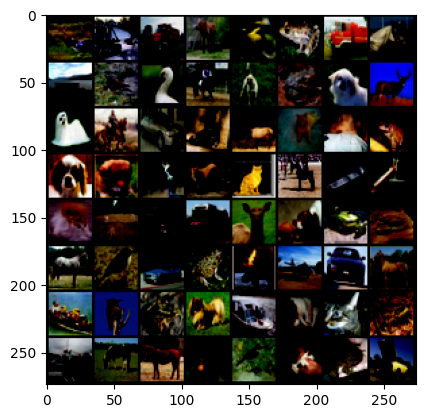

Label: 4


In [7]:
# TODO: load a random batch of test set images
import matplotlib.pyplot as plt

train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]

grid_img = torchvision.utils.make_grid(train_features)

# TODO: show the images
plt.imshow(grid_img.permute(1, 2, 0), cmap="gray")
plt.show()


# TODO: print the ground truth class labels for these images
print(f"Label: {label}")


## 3. Model Design (Total 22pts)

### 3.1 Define a neural network model: (2+7+7 =16pts)
- Name the model class with your first name
- In the following sequential order, the model should consist:

    (1) a 2D convolution layer with 6 filters, dimension of each filter is (5, 5), stride=1, no zero padding
    
    (2) a Max Pool layer with filter size (2, 2), stride=2
    
    (3) a 2D convolution layer with 16 filters, dimension of each filter is (5, 5), stride=1, no zero padding

    (4) a 2D Max Pool layer with filter size (2, 2), stride=2
    
    ~ a flatten layer ~

    (5) a Dense/Fully-connected layer with 120 neurons
    
    ~ a ReLU activation ~
    
    ~ a Dropout Layer ~

    (6) a Dense/Fully-connected layer with 80 neurons
    
    ~ a ReLU activation ~

    (7) a Dense/Fully-connected layer with 10 neurons

Note: 
1. Flatten, ReLU and Dropout are not really "layers". They are operations with specific purpose. But in model construction in pytorch, they are abstracted as layers.
    
    Flatten is used to convert the 4th layer output to a 1D tensor so that it can be passed through the next fully-connected layer. Since each forward pass takes a batch of data, use the *start_dim* parameter of *torch.flatten()* appropriately to keep the batch dimension intact.
    
    ReLU is an activation that transforms the Dense Layer's linear output to a non-linear "active" output.
    
    Dropout is a regularization technique. Read more in slides. In this assignment, you can drop neurons with 50% probability. 

2. This dataset has 10 classes, hence the final layer consists 10 neurons. 

3. The model architecture is similar to the one you saw in in-class Quiz 2, with an extra dense layer in the end. 

    Read about building your custom model in pytorch here: https://pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html

    The official pytorch documentation on conv, flatten, rely, dense are also resourceful.


In [8]:
class Anish(torch.nn.Module):
    def __init__(self):
        # TODO: Initialize the layers
        super(Anish, self).__init__()
      
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=0)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Flatten layer
        self.flatten = nn.Flatten()

        # Dense layers
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(120, 80)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(80, 10)

    def forward(self, x):
        # TODO: Define the dataflow through the layers
       
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.relu1(x)
        x = self.maxpool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

### 3.2 Create an instance of the model class that you just prepared. (2pts)

In [9]:
# TODO:

model = Anish()

### 3.3 Set up Cross Entropy Loss as the loss function and *Adam* as the optimizer. Use a learning rate of your choice for the optimizer. (4pts) 


In [10]:
# TODO: Define the loss function and optimizer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)


data  sample_data


## 4. Training and Validation (Total 50pts)


### 4.1 Write a training loop to load data, compute model output, compute loss and backpropagating it to update model parameters. (30pts)

The # TODO tags below contain further instructions. 

In [13]:
# TODO: Define number of epochs
epochs = 20

from datetime import datetime
from google.colab import drive
drive.mount('/content/drive')


# TODO: Initialize empty lists to store training loss, training accuracy, validation loss, validation accuracy 
# You will use these lists to plot the loss history.
training_loss = []
training_acc = []
validation_loss = []
validation_acc = []



# TODO: Loop through the number of epochs
for epoch in range(epochs):
    running_loss = 0
    correct = 0
    # TODO: set model to train mode
    model.train(mode=True)
    
    # TODO: iterate over the training data in batches
    for i, data in enumerate(train_dataloader):
        
        # TODO: get the image inputs and labels from current batch
        inputs, labels = data
        
        # TODO: set the optimizer gradients to zero to avoid accumulation of gradients
        optimizer.zero_grad()

        # TODO: compute the output of the model
        outputs = model(inputs)

        # TODO: compute the loss on current batch
        loss = loss_fn(outputs, labels)
        
        
        # TODO: backpropagate the loss
        loss.backward()

        # TODO: update the optimizer parameters
        optimizer.step()

        # TODO: update the train loss and accuracy
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()

    # TODO: compute the average training loss and accuracy and store in respective arrays
    avg_train_loss = running_loss / len(train_dataloader)
    avg_train_acc = 100 * correct / len(train_set)

    training_loss.append(avg_train_loss)
    training_acc.append(avg_train_acc)

    # TODO: set the model to evaluation mode
    model.eval()

    # TODO: keeping the gradient computation turned off, loop over batches of data from validation set.
    running_vloss = 0 
    vcorrect = 0
    for i, vdata in enumerate(valid_dataloader):
            # TODO: compute output of the model
            vinputs, vlabels = vdata
            voutputs = model(vinputs)

            # TODO: compute the loss
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss.item() * vinputs.size(0)
            
            # TODO: compute the validation loss and accuracy
            _, predicted = torch.max(voutputs.data, 1)
            vcorrect += (predicted == vlabels).sum().item()
            

    # TODO: compute the average validation loss and accuracy and store in respective lists
    avg_valid_loss = running_vloss / len(valid_dataloader)
    avg_valid_acc = 100 * vcorrect / len(valid_set)

    validation_loss.append(avg_valid_loss)
    validation_acc.append(avg_valid_acc)

    # TODO: print the training loss, training accuracy, validation loss and validation accuracy at the end of each epoch
    print(f"Epoch {epoch+1}/{epochs} - Training Loss: {avg_train_loss:.4f} - Training Acc: {avg_train_acc:.2f}% - Validation Loss: {avg_valid_loss:.4f} - Validation Acc: {avg_valid_acc:.2f}%")


    # TODO: save the model parameters once in every 5 epochs
    if (epoch % 5 == 0):
      model_path = f'/content/drive/My Drive/model_{epoch}.pt'
      torch.save(model.state_dict(), model_path)
      model_path = f'/content/my_models/model_{epoch}.pt'
      torch.save(model.state_dict(), model_path)
    

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/20 - Training Loss: 102.3967 - Training Acc: 41.30% - Validation Loss: 98.2424 - Validation Acc: 43.96%
Epoch 2/20 - Training Loss: 100.7569 - Training Acc: 42.51% - Validation Loss: 95.9135 - Validation Acc: 45.56%
Epoch 3/20 - Training Loss: 99.1952 - Training Acc: 43.70% - Validation Loss: 94.6398 - Validation Acc: 46.04%
Epoch 4/20 - Training Loss: 97.5581 - Training Acc: 44.49% - Validation Loss: 93.0578 - Validation Acc: 47.41%
Epoch 5/20 - Training Loss: 96.5400 - Training Acc: 45.12% - Validation Loss: 91.7473 - Validation Acc: 47.91%
Epoch 6/20 - Training Loss: 95.1527 - Training Acc: 46.00% - Validation Loss: 90.3351 - Validation Acc: 48.84%
Epoch 7/20 - Training Loss: 93.8905 - Training Acc: 46.58% - Validation Loss: 89.2042 - Validation Acc: 49.63%
Epoch 8/20 - Training Loss: 92.9339 - Training Acc: 47.13% - Validation Loss: 88.4262 - Vali

### 4.2 Plot and compare (5+5 =10pts)
1. training and validation loss over the number of epochs
2. training and validation accuracy over the number of epochs

(Hint: Use plot() from *matplotlib.pyplot*, import it if you haven't already done so.)

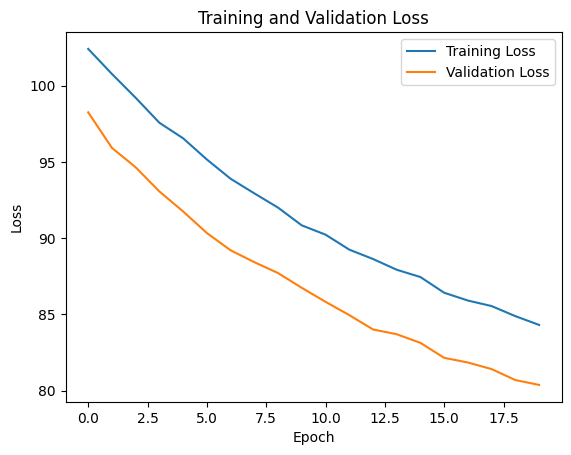

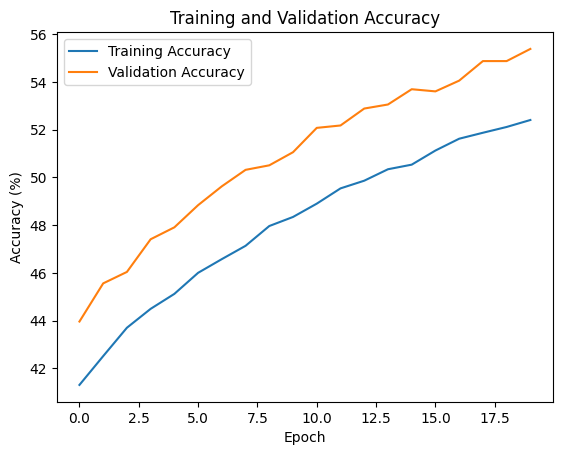

In [14]:
# convert tensors to numpy arrays
import numpy as np

# Plot training and validation loss
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(training_acc, label='Training Accuracy')
plt.plot(validation_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

### 4.3 Discussion: (2*5 = 10pts)
(1) Does the training loss and accuracy improve as number of epoch increases?

(2) Does the validation loss and accuracy improve as number of epoch increases?

(3) Are there any sign of overfitting in the results? If so, when did it start to occur?

(4) How many epochs did it take for the model to converge to a good solution?

(5) What enhancement can be tried to the architecture to further improve the validation performance?

~ # TODO

1) The training loss and accuracy is improving with each epoch. Previously with a higher learning rate, it did not seem that way.

2) The same can be said for the validation loss and accuracy as the training loss and accuracy.

3) There seems to be no sign of overfitting. There were signs of it prior with a higher learning rate.

4) The model seems to be converging to a good solution around epoch 18

5) Changing the learning rate over time could improve the validation performance

## 5. Testing on new data (Total 40pts)


### 5.1 Load the best performing model (one with good validation accuracy and without overfitting) among the ones you saved. (4pts)

In [22]:
# TODO: instantiate a model
model2 = torch.load('/content/my_models/model_15.pt')

# TODO: load parameters from one of the saved model states
model.load_state_dict(model2)

# TODO: set this model to evaluation mode 
model.eval()


Anish(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=120, out_features=80, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=80, out_features=10, bias=True)
)

### 5.2 Take a random batch of images from test set and show the images. Print the corresponding ground truth class labels. Then compute model output (model selected at previous step) and the predicted labels for the images in this batch. (10pts)

This is similar to task #2.5 with additional task on computing model output and printing predicted labels.

Feature batch shape: torch.Size([64, 3, 32, 32])
Labels batch shape: torch.Size([64])


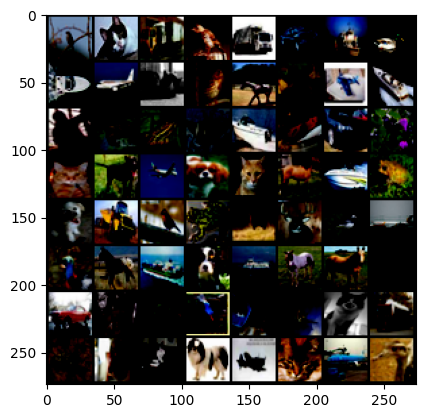

Label: 2
tensor([6, 0, 9, 4, 8, 7, 9, 0, 8, 6, 1, 6, 1, 6, 0, 0, 8, 4, 4, 6, 6, 5, 5, 4,
        7, 9, 8, 7, 8, 0, 8, 9, 7, 9, 0, 3, 9, 4, 5, 9, 5, 9, 0, 8, 4, 5, 6, 5,
        9, 7, 0, 1, 9, 7, 1, 6, 3, 3, 9, 2, 0, 4, 1, 7])


In [27]:
# TODO: load a random batch of test set images

test_features, test_labels = next(iter(test_dataloader))
print(f"Feature batch shape: {test_features.size()}")
print(f"Labels batch shape: {test_labels.size()}")
img = test_features[0].squeeze()
label = test_labels[0]

grid_img = torchvision.utils.make_grid(test_features)


# TODO: show the images
plt.imshow(grid_img.permute(1, 2, 0), cmap="gray")
plt.show()

# TODO: print the ground truth class labels for these images
print(f"Label: {label}")

# TODO: compute model output
outputs2 = model(test_features)

# TODO: print the predicted class labels for these images
_, predicted = torch.max(outputs.data, 1)
print(predicted)


### 5.3 Compute the average accuracy on test data using this model. (4+2 =6pts)
Loop over the test set, compute accuracy on each batch, lastly print the average accuracy. 

In [39]:
# TODO: compute accuracy on each batch of test set
total_predictions = 0
correct_predictions = 0
predicted_labels = torch.tensor([], dtype=torch.long)
with torch.no_grad():
    for inputs, labels in test_dataloader:
        
        # Forward pass through the model to get the predicted outputs
        outputs = model(inputs)
        
        # Compute the predicted class labels for this batch
        _, predicted = torch.max(outputs, 1)
        predicted_labels = torch.cat((predicted_labels, predicted))
        
        # Update the total and correct predictions
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels.squeeze()).sum().item()

# TODO: print the average accuracy
accuracy = correct_predictions / total_predictions

print('Test accuracy: {:.2f}%'.format(accuracy * 100))


Test accuracy: 54.24%


### 5.4 Compute the average accuracy for each individual class. (8+4 =12pts)
Hint: similar to #5.3. During each loop, log the accuracy for each class separately (a python/numpy dictionary can help). Then print the individual accuracy for the 10 output classes. 

In [58]:
# TODO: compute per-class accuracy on each batch of test set
class_accuracy = {}
class_total = {}

for i in range(10):
    class_accuracy[i] = 0
    class_total[i] = 0

model.eval()

with torch.no_grad():
    for images, labels in test_dataloader:
        # Forward pass
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(10):
            class_indices = torch.where(labels == i)[0]
            class_predictions = predicted[class_indices]
            if len(class_indices) > 0:
                class_accuracy[i] += torch.sum(class_predictions == i).item()
                class_total[i] += len(class_indices)

# TODO: compute average accuracy for each individual class
for i in range(10):
    class_accuracy[i] /= class_total[i]
    # TODO: print per-class accuracy for 10 output classes
    print("Accuracy for class {}: {:.2f}%".format(i, class_accuracy[i]*100))

Accuracy for class 0: 53.98%
Accuracy for class 1: 71.24%
Accuracy for class 2: 32.58%
Accuracy for class 3: 33.22%
Accuracy for class 4: 40.72%
Accuracy for class 5: 39.98%
Accuracy for class 6: 70.04%
Accuracy for class 7: 62.72%
Accuracy for class 8: 74.24%
Accuracy for class 9: 62.24%


### 5.5 Discussion: (2+2+4 =8pts)
1. Which class of images were detected with highest accuracy? 
2. Which class of images were hardest for the model to detect? 
3. Explain 1-2 possible reasons why detection of some class can be harder for the same model. 

~ # TODO

1) Class 8 was detected with the highest accuracy

2) Class 3 was the hardest to detect as it had an accuracy of 33%

3) Some classes may have fewer samples than others. If a class has large variations it may also be hard for the model to detect.